# Multi-Source ELT Pipeline: Airbyte → Snowflake → dbt

Airbyte loads a Google Sheets survey and two CSV trading files into Snowflake; dbt builds staging views and a trade-level fact table (joined with Snowflake Marketplace stock and FX data); pandas and matplotlib handle the analysis.

## 1. Accounts
Airbyte Cloud handles ingestion; a Snowflake account is the warehouse.

## 2. Install dbt (via Miniconda)

In [ ]:
!which dbt

## 3. Snowflake setup
Warehouse, databases, role, grants, and schemas. The SQL was run in a Snowflake worksheet and is kept here, commented out, for reference.

In [161]:
# -- Transaction 1: Setup warehouse and databases
# BEGIN;

# USE ROLE ACCOUNTADMIN;

# CREATE WAREHOUSE IF NOT EXISTS ELT_WAREHOUSE
#     WITH WAREHOUSE_SIZE = 'XSMALL'
#     AUTO_SUSPEND = 3600
#     AUTO_RESUME = TRUE
#     INITIALLY_SUSPENDED = TRUE;

# CREATE DATABASE IF NOT EXISTS SURVEY_DATABASE;
# CREATE DATABASE IF NOT EXISTS STOCK_DB;

# COMMIT;

# -- Transaction 2: Create role and grant permissions
# BEGIN;

# CREATE ROLE IF NOT EXISTS ELT_ROLE;
# GRANT ROLE ELT_ROLE TO ROLE SYSADMIN;

# GRANT USAGE ON WAREHOUSE ELT_WAREHOUSE TO ROLE ELT_ROLE;
# GRANT ROLE ELT_ROLE TO USER <your_user>;
# GRANT OWNERSHIP ON DATABASE SURVEY_DATABASE TO ROLE ELT_ROLE;
# GRANT OWNERSHIP ON DATABASE STOCK_DB TO ROLE ELT_ROLE;

# COMMIT;

# -- Transaction 3: Create schemas, grant ownership, switch to ELT_ROLE
# BEGIN;

# CREATE SCHEMA IF NOT EXISTS SURVEY_DATABASE.SURVEY_SCHEMA;
# CREATE SCHEMA IF NOT EXISTS STOCK_DB.STOCK_SCHEMA;

# GRANT OWNERSHIP ON SCHEMA SURVEY_DATABASE.SURVEY_SCHEMA 
# TO ROLE ELT_ROLE COPY CURRENT GRANTS;
# GRANT OWNERSHIP ON SCHEMA STOCK_DB.STOCK_SCHEMA TO 
# ROLE ELT_ROLE COPY CURRENT GRANTS;

# USE ROLE ELT_ROLE;

# COMMIT;

## 4. Airbyte source: survey responses (Google Sheets)

## 5. Airbyte sources: `trading_books.csv` and `weights_table.csv`

## 6. Airbyte → Snowflake connections

## 7. Landed data in Snowflake
`STOCK_SCHEMA.TRADING_BOOKS`, `STOCK_SCHEMA.WEIGHTS_TABLE`, and `SURVEY_SCHEMA.SURVEY` are populated by Airbyte. Console screenshots are omitted because the raw survey table contains respondent emails.

## 8. dbt: normalize survey column names
The `transform_survey` view renames long survey-question columns to short snake_case fields.

In [130]:
! cat ~/.dbt/profiles.yml | grep -v password


elt_pipeline:

  target: dev

  outputs:

    dev:

      type: snowflake

      account: <account_identifier>

      user: <your_user>


      role: ELT_ROLE

      database: SURVEY_DATABASE

      warehouse: ELT_WAREHOUSE

      schema: SURVEY_SCHEMA

      threads: 1

    stock_db:

      type: snowflake

      account: <account_identifier>

      user: <your_user>


      role: ELT_ROLE

      database: STOCK_DB

      warehouse: ELT_WAREHOUSE

      schema: STOCK_SCHEMA

      threads: 1



In [131]:
! cat dbt_pipeline/models/schema.yml

version: 2

sources:
  - name: airbyte_survey_data
    database: SURVEY_DATABASE
    schema: SURVEY_SCHEMA
    tables:
      - name: SURVEY

  - name: snowflake_public_data
    database: SNOWFLAKE_PUBLIC_DATA_FREE
    schema: PUBLIC_DATA_FREE
    tables:
      - name: STOCK_PRICE_TIMESERIES_PIT
      - name: FX_RATES_TIMESERIES_PIT

  - name: airbyte_csv_data
    database: STOCK_DB
    schema: STOCK_SCHEMA
    tables:
      - name: TRADING_BOOKS
      - name: WEIGHTS_TABLE


In [132]:
! cat dbt_pipeline/models/staging/transform_survey.sql

SELECT
    EMAIL_ADDRESS AS email,
    WHAT_IS_YOUR_AGE AS age,
    DO_YOU_OWN_A_VR_HEADSET AS vr_headset,
    DO_YOU_PREFER_CATS_OR_DOGS AS cats_or_dogs,
    WHAT_IS_YOUR_CURRENT_STANDING AS standing,
    WHAT_IS_YOUR_FAVORITE_TV_SHOW AS favorite_show,
    "WHEN_DO_YOU_PREFER_TO_TAKE_EXAMS" AS exam_preference,
    "_WHAT_IS_YOUR_PREFERRED_BEVERAGE_" AS preferred_beverage,
    "WHAT_IS_YOUR_FAVORITE_ICE_CREAM_FLAVOR" AS ice_cream_flavor,
    "_WHAT_IS_YOUR_FAVORITE_SEASON_OF_THE_YEAR_" AS favorite_season,
    WHAT_IS_YOUR_FAVORITE_OR_PREFERRED_LLM_TO_USE AS preferred_llm,
    WHAT_FACTOR_INFLUENCES_YOUR_COURSE_SELECTION_THE_MOST AS course_factor,
    WOULD_YOU_DESCRIBE_YOURSELF_AS_AN_EARLY_BIRD_OR_A_NIGHT_OWL AS early_or_night,
    "IF_YOU_HAVE_SECONDARY_MAJORS_PLEASE_LIST_THEM_HERE_SEPARATED_BY_A_COMMA" AS secondary_majors,
    "_WHICH_BEST_DESCRIBES_YOUR_PRIMARY_MAJOR_OR_FIELD_OF_STUDY_IF_YOU_HAVE_MORE_THAN_ONE_MAJOR_PLEASE_SPECIFY_OTHER_MAJORS_AS_PART_OF_THE_NEXT_QUESTION" AS primar

## 9. Survey analysis (Snowflake + pandas)

In [133]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt

import os

password = os.environ["SNOWFLAKE_PASSWORD"]

conn = snowflake.connector.connect(
    user=os.environ["SNOWFLAKE_USER"],
    password=password,
    account=os.environ["SNOWFLAKE_ACCOUNT"],
    warehouse='ELT_WAREHOUSE',
    database='SURVEY_DATABASE',
    schema='SURVEY_SCHEMA',
    role='ELT_ROLE'
)

In [134]:
def run_query(query):
    cur = conn.cursor()
    cur.execute(query)
    df = pd.DataFrame(cur.fetchall(), columns=[desc[0] for desc in cur.description])
    return df

In [ ]:
run_query("SELECT * FROM TRANSFORM_SURVEY LIMIT 15")

### Respondents by standing

In [136]:
df = run_query("""
    SELECT STANDING, COUNT(*) AS count 
    FROM TRANSFORM_SURVEY 
    GROUP BY STANDING 
    ORDER BY count DESC
""")
df

,STANDING,COUNT
0,Senior (or above),62
1,Junior,32
2,Sophomore,16
3,Graduate Student,10


### Most popular pet preference

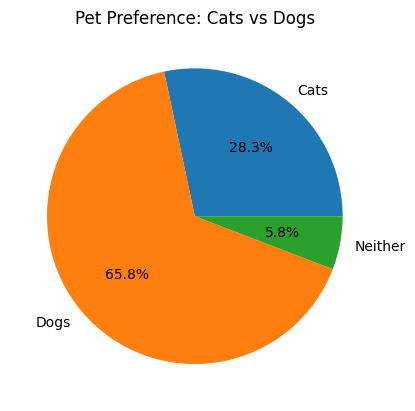

In [137]:
df = run_query("""
    SELECT CATS_OR_DOGS, COUNT(*) AS count 
    FROM TRANSFORM_SURVEY 
    GROUP BY CATS_OR_DOGS
""")
plt.pie(df['COUNT'], labels=df['CATS_OR_DOGS'], autopct='%1.1f%%')
plt.title('Pet Preference: Cats vs Dogs')
plt.show()

### Preferred LLM

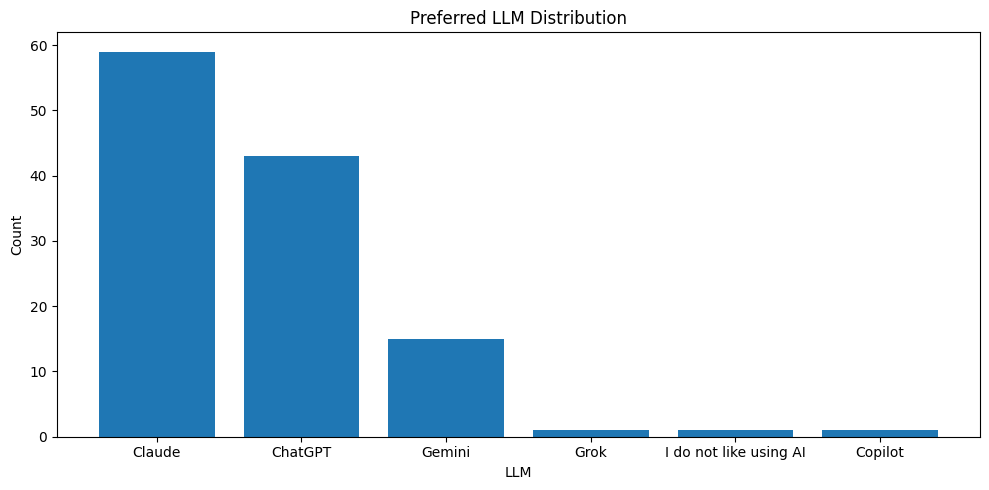

In [138]:
df = run_query("""
    SELECT PREFERRED_LLM, COUNT(*) AS count 
    FROM TRANSFORM_SURVEY 
    GROUP BY PREFERRED_LLM 
    ORDER BY count DESC
""")
plt.figure(figsize=(10,5))
plt.bar(df['PREFERRED_LLM'], df['COUNT'])
plt.title('Preferred LLM Distribution')
plt.xlabel('LLM')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Course-selection factors

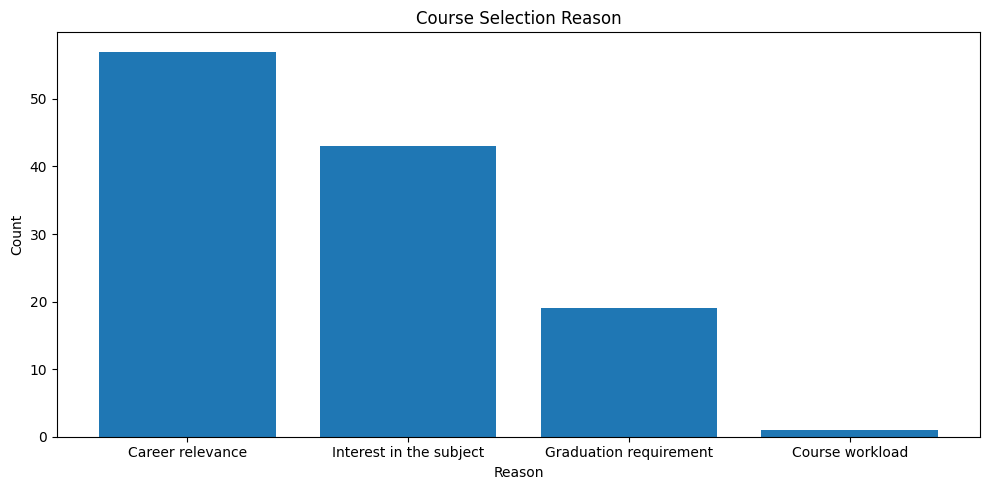

In [139]:
df = run_query("""
    SELECT COURSE_FACTOR, COUNT(*) AS count 
    FROM TRANSFORM_SURVEY 
    GROUP BY COURSE_FACTOR 
    ORDER BY count DESC
""")
plt.figure(figsize=(10,5))
plt.bar(df['COURSE_FACTOR'], df['COUNT'])
plt.title('Course Selection Reason')
plt.xlabel('Reason')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Oldest respondents within each standing (`RANK() OVER`)
Output cleared: the result rows contain respondent emails.

In [ ]:
df = run_query("""
    SELECT EMAIL, AGE, STANDING,
        RANK() OVER (PARTITION BY STANDING ORDER BY AGE DESC) AS age_rank
    FROM TRANSFORM_SURVEY
""")
df

### VR headset ownership vs. preferred LLM

In [141]:
df = run_query("""
    SELECT VR_HEADSET, PREFERRED_LLM, COUNT(*) AS count 
    FROM TRANSFORM_SURVEY 
    GROUP BY VR_HEADSET, PREFERRED_LLM 
    ORDER BY VR_HEADSET, count DESC
""")
df

,VR_HEADSET,PREFERRED_LLM,COUNT
0,No,Claude,48
1,No,ChatGPT,37
2,No,Gemini,14
3,No,I do not like using AI,1
4,No,Copilot,1
5,Yes,Claude,11
6,Yes,ChatGPT,6
7,Yes,Grok,1
8,Yes,Gemini,1


### Beverage preference: early birds vs. night owls

In [142]:
df = run_query("""
    SELECT EARLY_OR_NIGHT, PREFERRED_BEVERAGE, COUNT(*) AS count 
    FROM TRANSFORM_SURVEY 
    GROUP BY EARLY_OR_NIGHT, PREFERRED_BEVERAGE 
    ORDER BY EARLY_OR_NIGHT, count DESC
""")
df 
#most strange result

,EARLY_OR_NIGHT,PREFERRED_BEVERAGE,COUNT
0,Early Bird,Coffee,11
1,Early Bird,Water,10
2,Early Bird,Juice,3
3,Early Bird,Tea,3
4,Early Bird,Other,1
5,Early Bird,Energy Drinks,1
6,Neither,Water,11
7,Neither,Coffee,2
8,Neither,Other,2
9,Neither,Soda,1


## 10. Snowflake Marketplace data
Stock prices (`STOCK_PRICE_TIMESERIES_PIT`) and FX rates (`FX_RATES_TIMESERIES_PIT`) come from the free `SNOWFLAKE_PUBLIC_DATA_FREE` share.

## 11. dbt profile for `STOCK_DB`

In [143]:
! cat ~/.dbt/profiles.yml | grep -v password


elt_pipeline:

  target: dev

  outputs:

    dev:

      type: snowflake

      account: <account_identifier>

      user: <your_user>


      role: ELT_ROLE

      database: SURVEY_DATABASE

      warehouse: ELT_WAREHOUSE

      schema: SURVEY_SCHEMA

      threads: 1

    stock_db:

      type: snowflake

      account: <account_identifier>

      user: <your_user>


      role: ELT_ROLE

      database: STOCK_DB

      warehouse: ELT_WAREHOUSE

      schema: STOCK_SCHEMA

      threads: 1



## 12. Register the new sources in `schema.yml`

In [144]:
!cat dbt_pipeline/models/schema.yml

version: 2

sources:
  - name: airbyte_survey_data
    database: SURVEY_DATABASE
    schema: SURVEY_SCHEMA
    tables:
      - name: SURVEY

  - name: snowflake_public_data
    database: SNOWFLAKE_PUBLIC_DATA_FREE
    schema: PUBLIC_DATA_FREE
    tables:
      - name: STOCK_PRICE_TIMESERIES_PIT
      - name: FX_RATES_TIMESERIES_PIT

  - name: airbyte_csv_data
    database: STOCK_DB
    schema: STOCK_SCHEMA
    tables:
      - name: TRADING_BOOKS
      - name: WEIGHTS_TABLE


## 13. `dbt_project.yml`

In [145]:
!cat dbt_pipeline/dbt_project.yml

name: 'elt_pipeline'
version: '1.0.0'
profile: 'elt_pipeline'
model-paths: ["models"]
analysis-paths: ["analyses"]
test-paths: ["tests"]
seed-paths: ["seeds"]
macro-paths: ["macros"]
snapshot-paths: ["snapshots"]
clean-targets:
  - "target"
  - "dbt_packages"

models:
  elt_pipeline:
    staging:
      +materialized: view
      +snowflake_warehouse: ELT_WAREHOUSE
    marts:
      +materialized: table
      +snowflake_warehouse: ELT_WAREHOUSE


## 14. Staging models: FX and stock

### Connection

In [146]:
conn_stock = snowflake.connector.connect(
    user=os.environ["SNOWFLAKE_USER"],
    password=password,
    account=os.environ["SNOWFLAKE_ACCOUNT"],
    warehouse='ELT_WAREHOUSE',
    database='STOCK_DB',
    schema='STOCK_SCHEMA',
    role='ELT_ROLE'
)

def run_stock_query(query):
    cur = conn_stock.cursor()
    cur.execute(query)
    df = pd.DataFrame(cur.fetchall(), columns=[desc[0] for desc in cur.description])
    return df

### Models and results

In [147]:
!cat dbt_pipeline/models/staging/staging_valid_fx_tickers.sql

SELECT DISTINCT TICKER, TRADE_DATE
FROM {{ source('airbyte_csv_data', 'TRADING_BOOKS') }}
WHERE DESK = 'FX Desk'


In [148]:
run_stock_query("SELECT * FROM STAGING_VALID_FX_TICKERS")

,TICKER,TRADE_DATE
0,GBP/USD,2024-03-01
1,EUR/USD,2024-03-05
2,EUR/USD,2024-03-04
3,GBP/USD,2024-03-05
4,EUR/USD,2024-03-01
5,GBP/USD,2024-03-04


In [149]:
!cat dbt_pipeline/models/staging/staging_valid_stock_tickers.sql

SELECT DISTINCT TICKER, TRADE_DATE
FROM {{ source('airbyte_csv_data', 'TRADING_BOOKS') }}
WHERE DESK = 'Equity Desk'


In [150]:
run_stock_query("SELECT * FROM STAGING_VALID_STOCK_TICKERS")

,TICKER,TRADE_DATE
0,GOOGL,2024-03-01
1,MSFT,2024-03-05
2,MSFT,2024-03-01
3,MSFT,2024-03-04
4,AAPL,2024-03-04
5,GOOGL,2024-03-05
6,AAPL,2024-03-01
7,AAPL,2024-03-05
8,GOOGL,2024-03-04


In [151]:
 !cat dbt_pipeline/models/staging/staging_valid_stock_info.sql

SELECT
    s.TICKER,
    s.TRADE_DATE,
    sp.VARIABLE,
    sp.VALUE
FROM {{ ref('staging_valid_stock_tickers') }} s
JOIN {{ source('snowflake_public_data', 'STOCK_PRICE_TIMESERIES_PIT') }} sp
    ON s.TICKER = sp.TICKER AND s.TRADE_DATE = sp.DATE
WHERE sp.VARIABLE IN ('all-day_high', 'all-day_low')


In [152]:
run_stock_query("SELECT * FROM STAGING_VALID_STOCK_INFO")

,TICKER,TRADE_DATE,VARIABLE,VALUE
0,GOOGL,2024-03-04,all-day_low,131.910
1,AAPL,2024-03-04,all-day_low,173.795
2,MSFT,2024-03-01,all-day_low,410.880
3,MSFT,2024-03-01,all-day_high,415.870
4,MSFT,2024-03-04,all-day_low,411.940
5,GOOGL,2024-03-05,all-day_low,130.660
6,GOOGL,2024-03-01,all-day_high,138.920
7,AAPL,2024-03-04,all-day_high,179.340
8,GOOGL,2024-03-05,all-day_high,133.240
9,GOOGL,2024-03-01,all-day_low,136.910


In [153]:
!cat dbt_pipeline/models/staging/staging_valid_fx_info.sql

SELECT
    f.TICKER,
    f.TRADE_DATE,
    fx.VARIABLE_NAME,
    fx.VALUE AS exchange_rate
FROM {{ ref('staging_valid_fx_tickers') }} f
JOIN {{ source('snowflake_public_data', 'FX_RATES_TIMESERIES_PIT') }} fx
    ON f.TRADE_DATE = fx.DATE
WHERE fx.BASE_CURRENCY_ID IN ('EUR', 'GBP')
    AND fx.QUOTE_CURRENCY_ID = 'USD'


In [154]:
run_stock_query("SELECT * FROM STAGING_VALID_FX_INFO")

,TICKER,TRADE_DATE,VARIABLE_NAME,EXCHANGE_RATE
0,GBP/USD,2024-03-01,GBP/USD Exchange Rate,1.2634
1,EUR/USD,2024-03-01,GBP/USD Exchange Rate,1.2634
2,GBP/USD,2024-03-01,GBP/USD Exchange Rate,1.2634
3,EUR/USD,2024-03-01,GBP/USD Exchange Rate,1.2634
4,EUR/USD,2024-03-04,GBP/USD Exchange Rate,1.2673
5,GBP/USD,2024-03-04,GBP/USD Exchange Rate,1.2673
6,GBP/USD,2024-03-05,GBP/USD Exchange Rate,1.2683
7,EUR/USD,2024-03-05,GBP/USD Exchange Rate,1.2683
8,EUR/USD,2024-03-04,EUR/USD Exchange Rate,1.0846
9,GBP/USD,2024-03-04,EUR/USD Exchange Rate,1.0846


## 15. Staging model: buy/sell trade pairs

In [155]:
!cat dbt_pipeline/models/staging/staging_buy_sell_joint.sql

SELECT
    b.TRADE_ID AS trade_id,
    b.TRADE_DATE AS trade_date,
    b.TRADER_NAME AS trader_name,
    b.DESK AS desk,
    b.TICKER AS ticker,
    b.QUANTITY AS quantity_buy,
    b.PRICE AS price_buy,
    s.QUANTITY AS quantity_sell,
    s.PRICE AS price_sell
FROM {{ source('airbyte_csv_data', 'TRADING_BOOKS') }} b
JOIN {{ source('airbyte_csv_data', 'TRADING_BOOKS') }} s
    ON b.TRADER_NAME = s.TRADER_NAME
    AND b.TRADE_DATE = s.TRADE_DATE
WHERE b.TRADE_TYPE = 'BUY'
    AND s.TRADE_TYPE = 'SELL'
ORDER BY b.TRADE_ID


In [156]:
run_stock_query("SELECT * FROM STAGING_BUY_SELL_JOINT")

,TRADE_ID,TRADE_DATE,TRADER_NAME,DESK,TICKER,QUANTITY_BUY,PRICE_BUY,QUANTITY_SELL,PRICE_SELL
0,1001.0,2024-03-01,John Smith,Equity Desk,AAPL,100.0,175.500,100.0,178.250
1,1003.0,2024-03-01,Sarah Johnson,FX Desk,EUR/USD,100000.0,1.085,100000.0,1.092
2,1005.0,2024-03-01,Michael Chen,Equity Desk,MSFT,50.0,405.750,50.0,408.500
3,1007.0,2024-03-01,Lisa Wong,FX Desk,GBP/USD,75000.0,1.265,75000.0,1.272
4,1009.0,2024-03-01,David Kim,Equity Desk,GOOGL,75.0,141.250,75.0,142.500
5,1011.0,2024-03-04,John Smith,Equity Desk,AAPL,150.0,176.250,150.0,179.500
6,1013.0,2024-03-04,Sarah Johnson,FX Desk,EUR/USD,125000.0,1.088,125000.0,1.095
7,1015.0,2024-03-04,Michael Chen,Equity Desk,MSFT,75.0,407.250,75.0,410.750
8,1017.0,2024-03-04,Lisa Wong,FX Desk,GBP/USD,100000.0,1.268,100000.0,1.275
9,1019.0,2024-03-04,David Kim,Equity Desk,GOOGL,100.0,142.250,100.0,144.500


## 16. Fact table: trade-level profit

In [157]:
!cat dbt_pipeline/models/marts/fact_tab_trading.sql

SELECT
    TRADE_ID,
    PRICE_BUY * QUANTITY_BUY AS BUY_MONEY,
    PRICE_SELL * QUANTITY_SELL AS SELL_MONEY,
    (PRICE_SELL * QUANTITY_SELL) - (PRICE_BUY * QUANTITY_BUY) AS PROFIT
FROM {{ ref('staging_buy_sell_joint') }}
ORDER BY TRADE_ID


In [158]:
run_stock_query("SELECT * FROM FACT_TAB_TRADING")

,TRADE_ID,BUY_MONEY,SELL_MONEY,PROFIT
0,1001.0,17550.00,17825.00,275.00
1,1003.0,108500.00,109200.00,700.00
2,1005.0,20287.50,20425.00,137.50
3,1007.0,94875.00,95400.00,525.00
4,1009.0,10593.75,10687.50,93.75
5,1011.0,26437.50,26925.00,487.50
6,1013.0,136000.00,136875.00,875.00
7,1015.0,30543.75,30806.25,262.50
8,1017.0,126800.00,127500.00,700.00
9,1019.0,14225.00,14450.00,225.00


## 17. Total profit by desk

In [159]:
run_stock_query("""
    SELECT 
        t.DESK,
        SUM(f.PROFIT) AS Total_Profit
    FROM FACT_TAB_TRADING f
    JOIN TRADING_BOOKS t
        ON f.TRADE_ID = t.TRADE_ID
    WHERE t.TRADE_TYPE = 'BUY'
    GROUP BY t.DESK
""")

,DESK,TOTAL_PROFIT
0,FX Desk,5000.00
1,Equity Desk,2718.75


## 18. Profit rate by desk

In [160]:
run_stock_query("""
    SELECT 
        t.DESK,
        (SUM(f.SELL_MONEY) - SUM(f.BUY_MONEY)) / NULLIF(SUM(f.BUY_MONEY), 0) AS Profit_Rate
    FROM FACT_TAB_TRADING f
    JOIN TRADING_BOOKS t
        ON f.TRADE_ID = t.TRADE_ID
    WHERE t.TRADE_TYPE = 'BUY'
    GROUP BY t.DESK
""")

,DESK,PROFIT_RATE
0,FX Desk,0.006342
1,Equity Desk,0.012701
